In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/Dataset/Dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil, os

local_dataset_path = "/content/Dataset"

if not os.path.exists(local_dataset_path):
    shutil.copytree(dataset_path, local_dataset_path)
    print("✅ Dataset copied to local disk")
else:
    print("Dataset already exists locally")

dataset_path = local_dataset_path

Dataset already exists locally


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

val_loader = DataLoader(
    full_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Total samples:", len(full_dataset))
print("Classes:", full_dataset.classes)

Total samples: 6323
Classes: ['F0', 'F1', 'F2', 'F3', 'F4']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=False)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, 5
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Dataset/Dataset/best_EfficientNet.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("✅ EfficientNet loaded successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ EfficientNet loaded successfully


In [ ]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

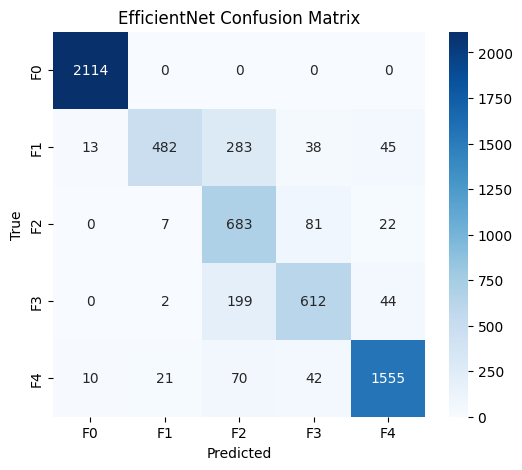

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["F0","F1","F2","F3","F4"],
            yticklabels=["F0","F1","F2","F3","F4"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNet Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=["F0","F1","F2","F3","F4"]
))

auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr"
)

print("Mean ROC-AUC:", auc)

              precision    recall  f1-score   support

          F0       0.99      1.00      0.99      2114
          F1       0.94      0.56      0.70       861
          F2       0.55      0.86      0.67       793
          F3       0.79      0.71      0.75       857
          F4       0.93      0.92      0.92      1698

    accuracy                           0.86      6323
   macro avg       0.84      0.81      0.81      6323
weighted avg       0.89      0.86      0.86      6323

Mean ROC-AUC: 0.9781134747034066


In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 32.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=faed4fb76b69b457f90a35b2f70b2e291aa39fc9e1f54e0c4e00ec51f5e5847c
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


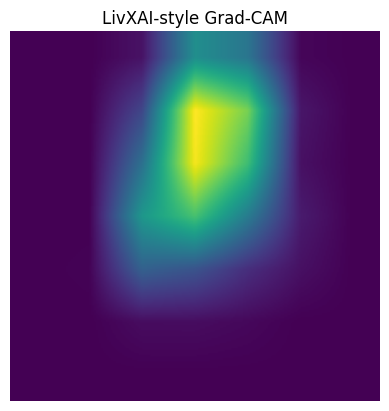

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.features[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

images, labels = next(iter(val_loader))
images = images.to(device)

grayscale_cam = cam(input_tensor=images)

plt.imshow(grayscale_cam[0])
plt.title("LivXAI-style Grad-CAM")
plt.axis("off")
plt.show()

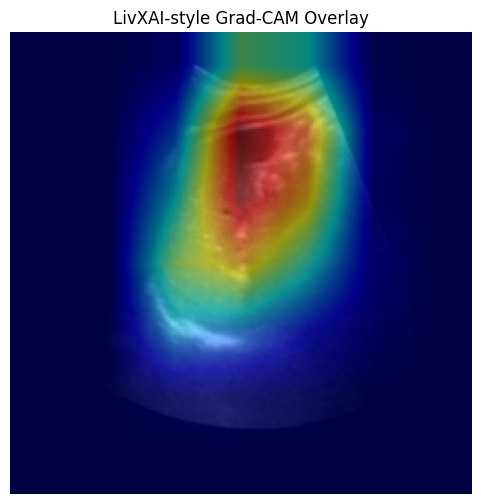

In [ ]:
import cv2
import numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

# Get one image
images, labels = next(iter(val_loader))
images = images.to(device)

# Generate Grad-CAM
grayscale_cam = cam(input_tensor=images)
cam_map = grayscale_cam[0]

# Convert tensor image to numpy
img = images[0].cpu().numpy().transpose(1, 2, 0)

# Undo normalization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

# Overlay
visualization = show_cam_on_image(img.astype(np.float32), cam_map, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.title("LivXAI-style Grad-CAM Overlay")
plt.axis("off")
plt.show()

In [ ]:
images, labels = next(iter(val_loader))
print(val_loader.dataset.samples[0])

('/content/Dataset/F0/a1000.jpg', 0)


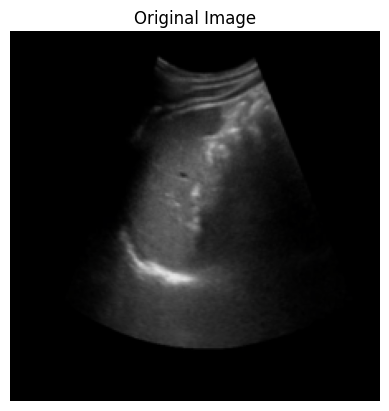

In [ ]:
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
def compute_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
from torch.utils.data import random_split, DataLoader

# Load full dataset
full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

total_size = len(full_dataset)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # important for reproducibility
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 4426
Validation: 948
Test: 949


In [ ]:
def compute_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [ ]:
train_acc = compute_accuracy(model, train_loader)
val_acc = compute_accuracy(model, val_loader)
test_acc = compute_accuracy(model, test_loader)

print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.8646633529145956
Validation Accuracy: 0.8481012658227848
Test Accuracy: 0.8587987355110642


In [ ]:
from torchvision import models
import torch.nn as nn

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Change classifier to 5 classes
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 5)

model = model.to(device)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
model.features[0]
model.features[1]
...
model.features[8]

Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)

In [ ]:
for param in model.features[7].parameters():
    param.requires_grad = True

for param in model.features[8].parameters():
    param.requires_grad = True

# Also classifier must be trainable
for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss()

In [ ]:
EPOCHS = 20
best_val_acc = 0

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1}/20 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_efficientnet_finetuned.pth")

print("✅ Best Val Acc:", best_val_acc)

Epoch 1/20 | Train Acc: 0.5558 | Val Acc: 0.7004
Epoch 2/20 | Train Acc: 0.7131 | Val Acc: 0.7342
Epoch 3/20 | Train Acc: 0.7653 | Val Acc: 0.8101
Epoch 4/20 | Train Acc: 0.8084 | Val Acc: 0.8449
Epoch 5/20 | Train Acc: 0.8333 | Val Acc: 0.8703
Epoch 6/20 | Train Acc: 0.8635 | Val Acc: 0.8903
Epoch 7/20 | Train Acc: 0.8825 | Val Acc: 0.9103
Epoch 8/20 | Train Acc: 0.8988 | Val Acc: 0.9314
Epoch 9/20 | Train Acc: 0.9166 | Val Acc: 0.9346
Epoch 10/20 | Train Acc: 0.9259 | Val Acc: 0.9420
Epoch 11/20 | Train Acc: 0.9356 | Val Acc: 0.9494
Epoch 12/20 | Train Acc: 0.9358 | Val Acc: 0.9409
Epoch 13/20 | Train Acc: 0.9394 | Val Acc: 0.9546
Epoch 14/20 | Train Acc: 0.9537 | Val Acc: 0.9557
Epoch 15/20 | Train Acc: 0.9528 | Val Acc: 0.9620
Epoch 16/20 | Train Acc: 0.9568 | Val Acc: 0.9599
Epoch 17/20 | Train Acc: 0.9571 | Val Acc: 0.9673
Epoch 18/20 | Train Acc: 0.9598 | Val Acc: 0.9694
Epoch 19/20 | Train Acc: 0.9602 | Val Acc: 0.9715
Epoch 20/20 | Train Acc: 0.9693 | Val Acc: 0.9736
✅ Best Va

In [ ]:
def compute_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


train_acc = compute_accuracy(model, train_loader)
val_acc = compute_accuracy(model, val_loader)
test_acc = compute_accuracy(model, test_loader)

print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 1.0
Validation Accuracy: 0.9736286919831224
Test Accuracy: 0.9789251844046365


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []
all_probs = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

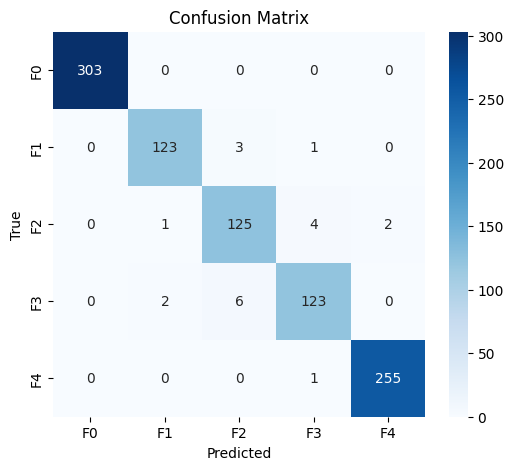

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["F0","F1","F2","F3","F4"],
            yticklabels=["F0","F1","F2","F3","F4"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=["F0","F1","F2","F3","F4"]
))

              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       303
          F1       0.98      0.97      0.97       127
          F2       0.93      0.95      0.94       132
          F3       0.95      0.94      0.95       131
          F4       0.99      1.00      0.99       256

    accuracy                           0.98       949
   macro avg       0.97      0.97      0.97       949
weighted avg       0.98      0.98      0.98       949



In [ ]:
def compute_sensitivity_specificity(cm):
    sensitivity = []
    specificity = []

    for i in range(len(cm)):
        TP = cm[i, i]
        FN = cm[i].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)

        sens = TP / (TP + FN)
        spec = TN / (TN + FP)

        sensitivity.append(sens)
        specificity.append(spec)

    return sensitivity, specificity


sens, spec = compute_sensitivity_specificity(cm)

for i, stage in enumerate(["F0","F1","F2","F3","F4"]):
    print(f"{stage} -> Sensitivity: {sens[i]:.4f} | Specificity: {spec[i]:.4f}")

F0 -> Sensitivity: 1.0000 | Specificity: 1.0000
F1 -> Sensitivity: 0.9685 | Specificity: 0.9964
F2 -> Sensitivity: 0.9470 | Specificity: 0.9890
F3 -> Sensitivity: 0.9389 | Specificity: 0.9927
F4 -> Sensitivity: 0.9961 | Specificity: 0.9971


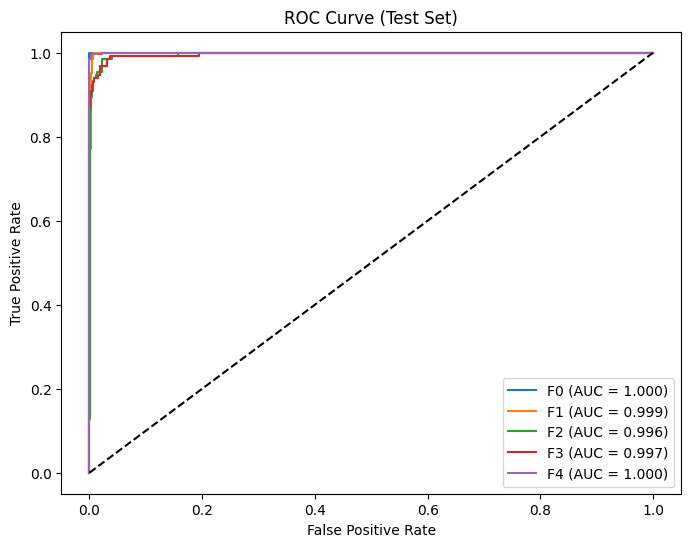

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = 5
labels_bin = label_binarize(all_labels, classes=[0,1,2,3,4])

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"F{i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

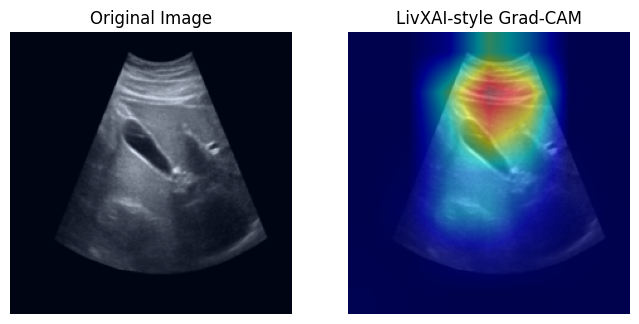

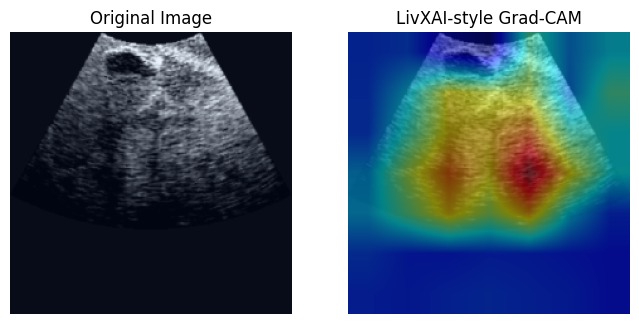

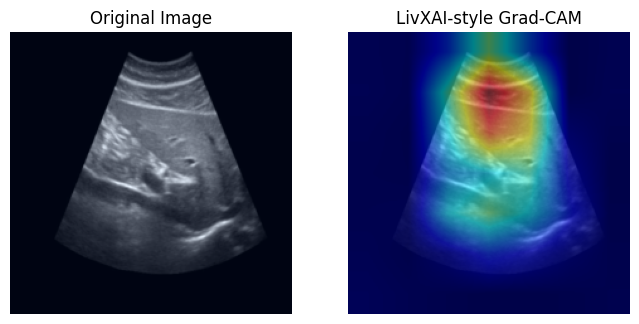

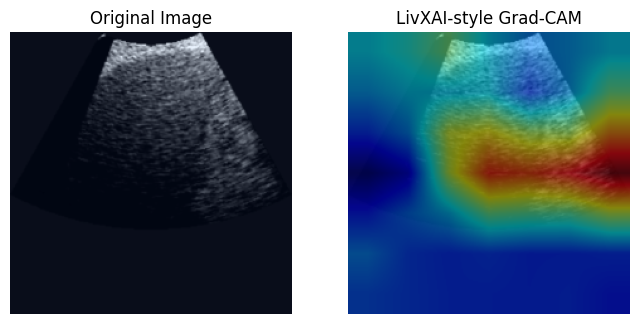

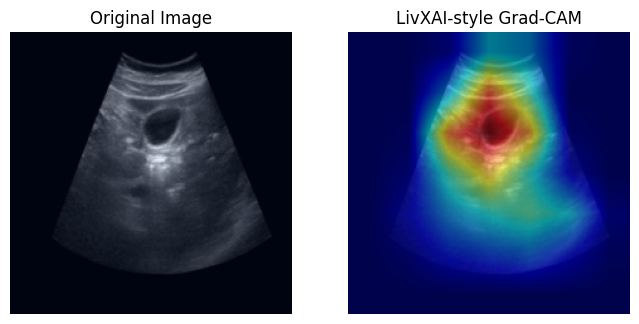

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

images, labels = next(iter(test_loader))
images = images.to(device)

grayscale_cam = cam(input_tensor=images)

for i in range(5):
    img = images[i].cpu().numpy().transpose(1,2,0)
    img = (img - img.min()) / (img.max() - img.min())

    visualization = show_cam_on_image(img, grayscale_cam[i], use_rgb=True)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title("LivXAI-style Grad-CAM")
    plt.axis("off")

    plt.show()

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ====== SETTINGS ======
class_names = ["F0", "F1", "F2", "F3", "F4"]
save_dir = "/content/drive/MyDrive/LivXAI_Results"
os.makedirs(save_dir, exist_ok=True)

model.eval()

# Target layer (EfficientNet last conv block)
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

print("🚀 Generating Grad-CAM and saving to Drive...\n")

for stage_idx, stage_name in enumerate(class_names):

    # Find one image from each class
    for img_path, label in val_loader.dataset.dataset.samples:
        if label == stage_idx:
            image_path = img_path
            break

    # Load image
    pil_image = Image.open(image_path).convert("RGB")
    img_resized = pil_image.resize((224, 224))
    img_np = np.array(img_resized)

    # Transform
    input_tensor = val_loader.dataset.dataset.transform(pil_image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Generate GradCAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    img_float = img_np.astype(np.float32) / 255.0
    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"{stage_name} Stage", fontsize=18, fontweight="bold")

    axes[0].imshow(img_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(visualization)
    axes[1].set_title("LivXAI Grad-CAM")
    axes[1].axis("off")

    plt.tight_layout()

    # Save high resolution image
    save_path = os.path.join(save_dir, f"{stage_name}_GradCAM.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"✅ Saved: {save_path}")

print("\n🎉 All Grad-CAM figures saved successfully!")

🚀 Generating Grad-CAM and saving to Drive...

✅ Saved: /content/drive/MyDrive/LivXAI_Results/F0_GradCAM.png
✅ Saved: /content/drive/MyDrive/LivXAI_Results/F1_GradCAM.png
✅ Saved: /content/drive/MyDrive/LivXAI_Results/F2_GradCAM.png
✅ Saved: /content/drive/MyDrive/LivXAI_Results/F3_GradCAM.png
✅ Saved: /content/drive/MyDrive/LivXAI_Results/F4_GradCAM.png

🎉 All Grad-CAM figures saved successfully!


🚀 Generating Grad-CAM for ALL stages...



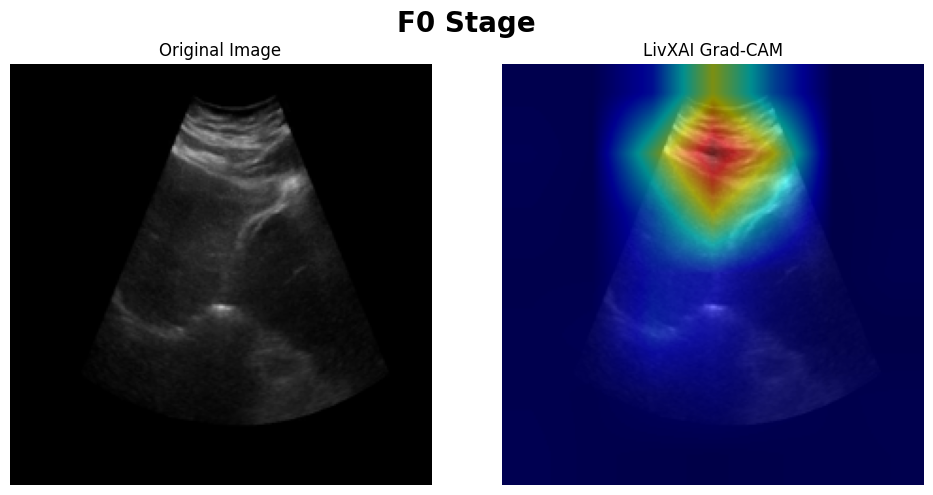

✅ Saved: /content/drive/MyDrive/LivXAI_Results/F0_GradCAM.png



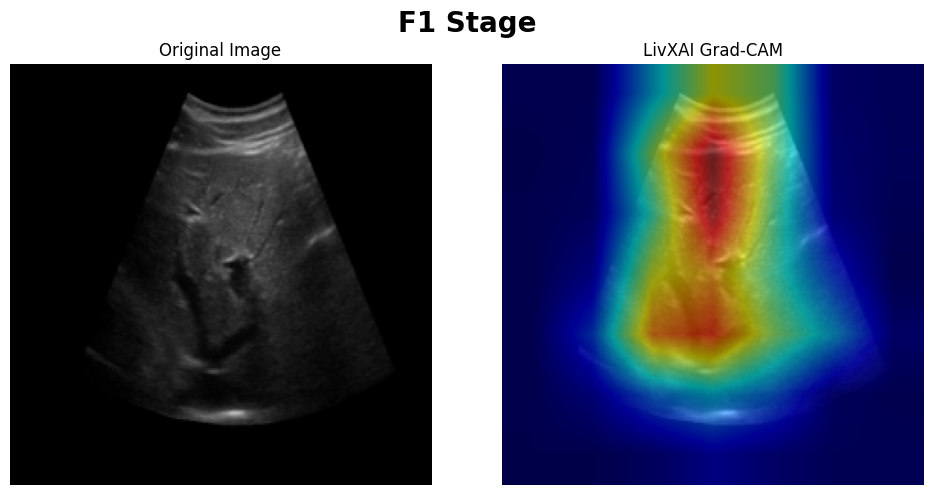

✅ Saved: /content/drive/MyDrive/LivXAI_Results/F1_GradCAM.png



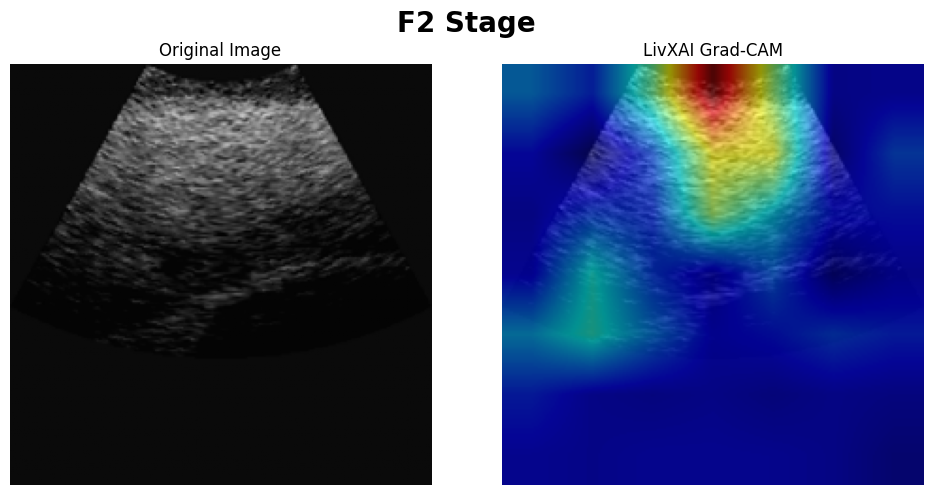

✅ Saved: /content/drive/MyDrive/LivXAI_Results/F2_GradCAM.png



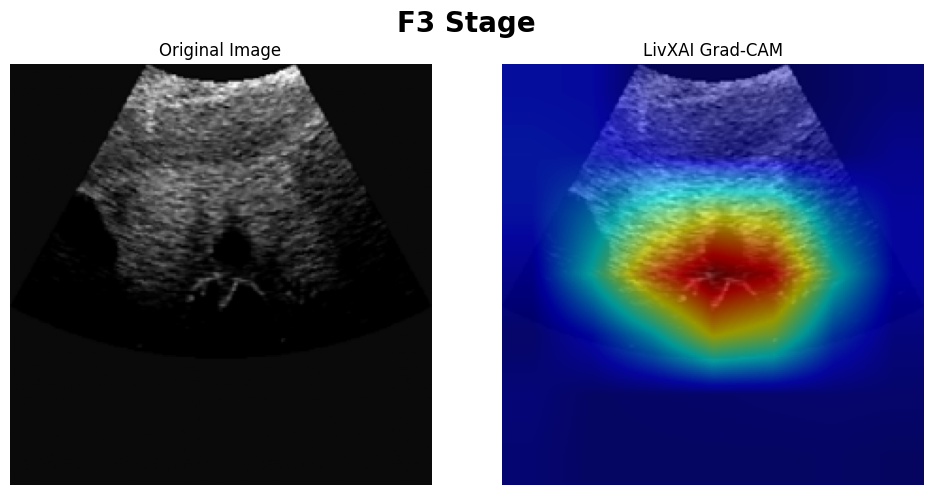

✅ Saved: /content/drive/MyDrive/LivXAI_Results/F3_GradCAM.png



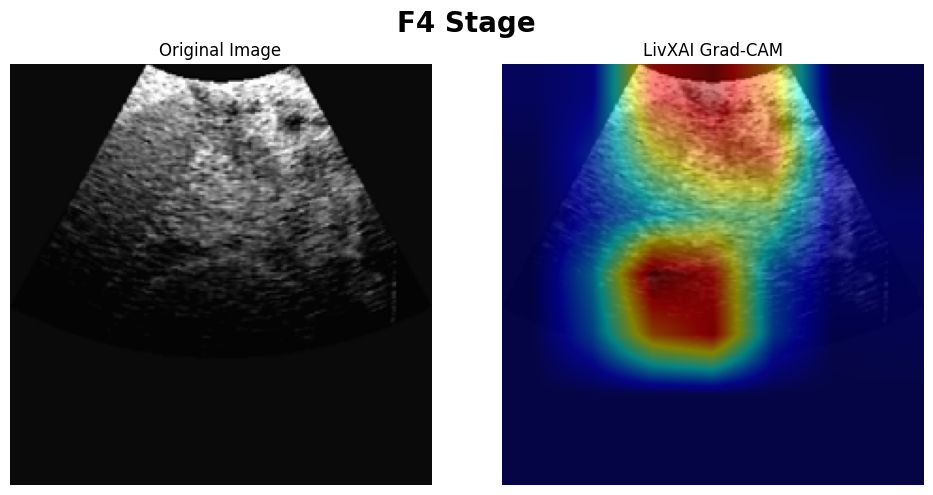

✅ Saved: /content/drive/MyDrive/LivXAI_Results/F4_GradCAM.png

🔥 ALL STAGES COMPLETED SUCCESSFULLY


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

# ===== CONFIG =====
stages = ["F0", "F1", "F2", "F3", "F4"]
dataset_root = "/content/Dataset"   # local copied dataset
save_dir = "/content/drive/MyDrive/LivXAI_Results"
os.makedirs(save_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# Use last conv layer of EfficientNet
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

print("🚀 Generating Grad-CAM for ALL stages...\n")

for stage_name in stages:

    stage_path = os.path.join(dataset_root, stage_name)
    image_name = os.listdir(stage_path)[0]
    image_path = os.path.join(stage_path, image_name)

    # Load original image
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((224, 224))
    img_np = np.array(img_resized) / 255.0

    # Transform for model
    input_tensor = val_loader.dataset.dataset.transform(img_resized)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Generate CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # ===== Plot =====
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"{stage_name} Stage", fontsize=20, fontweight="bold")

    axes[0].imshow(img_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(visualization)
    axes[1].set_title("LivXAI Grad-CAM")
    axes[1].axis("off")

    plt.tight_layout()

    # Save
    save_path = os.path.join(save_dir, f"{stage_name}_GradCAM.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")


    plt.show()

    print(f"✅ Saved: {save_path}\n")

print("🔥 ALL STAGES COMPLETED SUCCESSFULLY")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torchvision.models as models

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EfficientNet-B0
model = models.efficientnet_b0(weights=None)

# Modify classifier for 5 classes
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 5)

# Load your checkpoint
model_path = "/content/drive/MyDrive/Dataset/Dataset/efficientnet_checkpoint.pth"
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# Move to device
model = model.to(device)
model.eval()

print("EfficientNet loaded successfully")

EfficientNet loaded successfully


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = models.efficientnet_b0(pretrained=False)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 5)

model_path = "/content/drive/MyDrive/Dataset/Dataset/efficientnet_checkpoint.pth"
# Load the entire checkpoint dictionary
checkpoint = torch.load(model_path, map_location=device)
# Load only the model's state_dict from the checkpoint
model.load_state_dict(checkpoint['model_state_dict'])

model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat